🇬🇧 [English](03_model_development.ipynb) · 🇪🇸 [Español](03_model_development_es.ipynb)

# Cohorte PBC: validación anidada, tuning, y explicabilidad

Esta notebook responde la pregunta que deja abierta `02_modeling.ipynb`: **¿es un
único split 80/20 de test un número defendible para una cohorte de 412 filas?**

Ejecuta, en orden: validación cruzada anidada repetida
(`src/validation.nested_cv_evaluate`), corrección de optimismo bootstrap de Harrell
(`src/validation.bootstrap_optimism_correction`), tuning de hiperparámetros con Optuna
para el comparador primario (`src/hpo.run_hyperparameter_study`), y explicaciones SHAP
(`src/explainability.compute_shap_explanations`) para el modelo ajustado. Cierra con la
tabla de comparación split-único-vs-CV-anidada que es la afirmación empírica central de
este proyecto.

Investigación exploratoria sobre una cohorte histórica sin validación externa ni
temporal: **no para uso clínico, no es consejo médico, no reemplaza una biopsia ni la
evaluación de un clínico**.

In [1]:
import json
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd

_here = Path.cwd().resolve()
PROJECT_ROOT = next(p for p in [_here, *_here.parents]
                    if (p / "src" / "data.py").exists() and (p / "data" / "raw" / "pbc.csv").exists())
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from src.data import events_per_variable, load_pbc_data, train_test_split_pipeline
from src.evaluation import binary_metrics, prediction_stability, select_operating_threshold
from src.explainability import compute_shap_explanations, plot_shap_summary
from src.hpo import run_hyperparameter_study
from src.modeling import build_named_pipeline
from src.validation import bootstrap_optimism_correction, nested_cv_evaluate


In [2]:
DATA_PATH = PROJECT_ROOT / "data" / "raw" / "pbc.csv"
OUTPUT_DIR = PROJECT_ROOT / "outputs"
frame = load_pbc_data(DATA_PATH)
split = train_test_split_pipeline(frame, test_size=0.2, random_state=41)
MODELS = ("logistic", "random_forest", "hist_gradient_boosting", "lightgbm")
PRIMARY_MODEL = "hist_gradient_boosting"
print(f"Raíz del proyecto: {PROJECT_ROOT}")
print(f"Filas de train: {len(split.X_train)}; events-per-variable: {events_per_variable(split.X_train, split.y_binary_train):.2f}")


Raíz del proyecto: /home/datakrdo/Documents/portfolio/cirrhosis
Filas de train: 329; events-per-variable: 5.62


Esta notebook reutiliza el mismo split de producción que `02_modeling.ipynb`
(`train_test_split_pipeline`, estratificado por cohorte) así que sus números de split
único son directamente comparables, y luego va más allá con estimadores basados en
resampling que usan el fold de entrenamiento repetidamente en lugar de una sola vez.

Un ratio events-per-variable por debajo de 10 significa que los puntos estimados de
cualquier split individual son inestables; antes de confiar en un número principal, esa
inestabilidad tiene que cuantificarse, no asumirse como inexistente.

Los cuatro modelos preespecificados (`logistic`, `random_forest`,
`hist_gradient_boosting`, `lightgbm`) se comparan bajo CV anidada y corrección de
optimismo bootstrap; `hist_gradient_boosting` sigue siendo el comparador primario para
tuning y SHAP.

In [3]:
nested_results = {}
for name in MODELS:
    nested_results[name] = nested_cv_evaluate(
        split.X_train, split.y_binary_train, name,
        outer_splits=5, outer_repeats=5, inner_splits=3, random_state=41,
    )

nested_auroc = pd.DataFrame({
    name: {
        "mean": res["summary"]["auroc"]["mean"], "std": res["summary"]["auroc"]["std"],
        "ci_low": res["summary"]["auroc"]["ci_95"][0], "ci_high": res["summary"]["auroc"]["ci_95"][1],
    }
    for name, res in nested_results.items()
}).T
print("AUROC de CV anidada (5x5 folds externos estratificados repetidos, tuning de umbral en CV interna):")
print(nested_auroc.round(3).to_string())

[I 2026-09-19 18:00:24,345] A new study created in memory with name: no-name-ab17660f-29fd-4ccb-9b7b-01d9e1cdaa54


[I 2026-09-19 18:00:24,449] Trial 0 finished with value: 0.693362819664903 and parameters: {'C': 0.01797289837745552, 'splines': True}. Best is trial 0 with value: 0.693362819664903.


[I 2026-09-19 18:00:24,499] Trial 1 finished with value: 0.6955467372134039 and parameters: {'C': 0.0016494814210308672, 'splines': True}. Best is trial 1 with value: 0.6955467372134039.


[I 2026-09-19 18:00:24,548] Trial 2 finished with value: 0.695102375440917 and parameters: {'C': 0.009008517237663088, 'splines': True}. Best is trial 1 with value: 0.6955467372134039.


[I 2026-09-19 18:00:24,625] Trial 3 finished with value: 0.6782820767195767 and parameters: {'C': 0.12413676821551707, 'splines': False}. Best is trial 1 with value: 0.6955467372134039.


...

[I 2026-09-19 18:15:31,339] Trial 6 finished with value: 0.6461588541666666 and parameters: {'n_estimators': 79, 'learning_rate': 0.014595572624752771, 'num_leaves': 25, 'max_depth': 7, 'min_child_samples': 40}. Best is trial 0 with value: 0.6636284722222222.


[I 2026-09-19 18:15:32,717] Trial 7 pruned. 


[I 2026-09-19 18:15:34,130] Trial 8 pruned. 


[I 2026-09-19 18:15:34,807] Trial 9 pruned. 


AUROC de CV anidada (5x5 folds externos estratificados repetidos, tuning de umbral en CV interna):
                         mean    std  ci_low  ci_high
logistic                0.701  0.058   0.612    0.814
random_forest           0.697  0.063   0.579    0.816
hist_gradient_boosting  0.655  0.050   0.583    0.738
lightgbm                0.687  0.066   0.556    0.785


Cada uno de los 25 folds externos (5 splits x 5 repeticiones) reserva aproximadamente
66 filas, ajusta el preprocesamiento/selección de umbral solo con las filas de
entrenamiento restantes, y evalúa el fold intocado; la media y el IC resultantes
reflejan variabilidad entre folds que un único conjunto de test de 83 filas no puede
mostrar.

El resampling repetido es la alternativa estándar para muestra pequeña frente a un
único holdout en modelado de predicción clínica (Steyerberg, *Clinical Prediction
Models*); cambia un número único que se ve preciso por uno honesto y más amplio.

Estas medias e intervalos de CV anidada — no los números de split único de
`02_modeling.ipynb` — se tratan como las estimaciones principales de rendimiento.

In [4]:
optimism_results = {}
for name in MODELS:
    optimism_results[name] = bootstrap_optimism_correction(
        split.X_train, split.y_binary_train, name, n_boot=200, random_state=41,
    )

optimism_table = pd.DataFrame({
    name: {
        "apparent_auroc": res["apparent"]["auroc"],
        "corrected_auroc": res["corrected"]["auroc"],
        "optimism": res["optimism"]["auroc"],
    }
    for name, res in optimism_results.items()
}).T
print("Corrección de optimismo bootstrap de Harrell (n_boot=200):")
print(optimism_table.round(3).to_string())

Corrección de optimismo bootstrap de Harrell (n_boot=200):
                        apparent_auroc  corrected_auroc  optimism
logistic                         0.745            0.695     0.050
random_forest                    0.897            0.792     0.105
hist_gradient_boosting           0.834            0.738     0.096
lightgbm                         1.000            0.909     0.091


El rendimiento "apparent" reajusta cada modelo sobre 200 resamples bootstrap de los
datos de entrenamiento y lo evalúa sobre ese mismo resample; la brecha entre el
rendimiento apparent y el del conjunto de entrenamiento completo estima cuánto del
score aparente es sobreajuste en lugar de señal, y esa brecha se resta del score con
la muestra completa.

Los ensambles de árboles con pocas restricciones efectivas de regularización pueden
alcanzar un AUROC apparent casi perfecto sobre 329 filas de entrenamiento mientras
generalizan mucho peor — exactamente el modo de fallo que la CV anidada y la
corrección de optimismo están diseñadas para detectar.

Los números apparent, corregido, y de CV anidada se reportan lado a lado en lugar de
solo el número apparent; una brecha grande entre apparent y corregido es en sí misma un
hallazgo sobre el modelo, no ruido que se pueda descartar.

In [5]:
study = run_hyperparameter_study(
    split.X_train, split.y_binary_train,
    model_name=PRIMARY_MODEL, n_trials=30, random_state=41, cv=3,
)
print(f"Mejor AUROC de CV interna para {PRIMARY_MODEL} (búsqueda independiente de 3-fold): {study.best_value:.3f}")
print("Mejores hiperparámetros:", json.dumps(study.best_params, indent=2))
print(f"\nMedia propia ajustada de nested_cv_evaluate (celda anterior, tune_hyperparameters=True "
      f"por defecto): {nested_results[PRIMARY_MODEL]['summary']['auroc']['mean']:.3f}. "
      "Este estudio independiente es una búsqueda separada, más grande (30 trials) sobre un solo "
      "split de CV, mostrada para inspeccionar los hiperparámetros ganadores; no es en sí misma una "
      "estimación de rendimiento sin sesgo (reporta el máximo sobre 30 trials en un solo split de "
      "CV), así que no es el número que este proyecto reporta como rendimiento principal -- ese "
      "número viene de la celda anterior, donde cada fold externo re-ejecuta su propia búsqueda "
      "interna más pequeña (n_trials=10) antes de evaluarse, así que la media reportada ya incluye "
      "el costo del tuning.")

[I 2026-09-19 18:21:07,816] A new study created in memory with name: no-name-94388280-7bbe-4990-a96a-d6369b7f4ac9


[I 2026-09-19 18:21:08,314] Trial 0 finished with value: 0.6684440928270042 and parameters: {'max_iter': 200, 'max_depth': 2, 'learning_rate': 0.09994007137813693, 'l2_regularization': 0.2173474282237603, 'min_samples_leaf': 9}. Best is trial 0 with value: 0.6684440928270042.


[I 2026-09-19 18:21:08,968] Trial 1 finished with value: 0.7082489451476793 and parameters: {'max_iter': 342, 'max_depth': 3, 'learning_rate': 0.09715804671557356, 'l2_regularization': 4.587239244354484, 'min_samples_leaf': 20}. Best is trial 1 with value: 0.7082489451476793.


[I 2026-09-19 18:21:09,446] Trial 2 finished with value: 0.7100140646976091 and parameters: {'max_iter': 233, 'max_depth': 3, 'learning_rate': 0.018843496726467263, 'l2_regularization': 1.5855523524331532, 'min_samples_leaf': 22}. Best is trial 2 with value: 0.7100140646976091.


[I 2026-09-19 18:21:09,870] Trial 3 finished with value: 0.7155256680731364 and parameters: {'max_iter': 127, 'max_depth': 6, 'learning_rate': 0.029161911494066196, 'l2_regularization': 3.726411774596239, 'min_samples_leaf': 19}. Best is trial 3 with value: 0.7155256680731364.


...

[I 2026-09-19 18:21:27,304] Trial 26 pruned. 


[I 2026-09-19 18:21:28,101] Trial 27 finished with value: 0.7277707454289732 and parameters: {'max_iter': 182, 'max_depth': 7, 'learning_rate': 0.011250022251605221, 'l2_regularization': 2.9982085751086367, 'min_samples_leaf': 9}. Best is trial 22 with value: 0.7316385372714486.


[I 2026-09-19 18:21:28,685] Trial 28 finished with value: 0.7265418424753868 and parameters: {'max_iter': 152, 'max_depth': 6, 'learning_rate': 0.014040161942620696, 'l2_regularization': 3.3514260333395534, 'min_samples_leaf': 8}. Best is trial 22 with value: 0.7316385372714486.


[I 2026-09-19 18:21:30,429] Trial 29 pruned. 


Mejor AUROC de CV interna para hist_gradient_boosting (búsqueda independiente de 3-fold): 0.732
Mejores hiperparámetros: {
  "max_iter": 209,
  "max_depth": 8,
  "learning_rate": 0.014585941423745793,
  "l2_regularization": 2.8737233477287054,
  "min_samples_leaf": 5
}

Media propia ajustada de nested_cv_evaluate (celda anterior, tune_hyperparameters=True por defecto): 0.655. Este estudio independiente es una búsqueda separada, más grande (30 trials) sobre un solo split de CV, mostrada para inspeccionar los hiperparámetros ganadores; no es en sí misma una estimación de rendimiento sin sesgo (reporta el máximo sobre 30 trials en un solo split de CV), así que no es el número que este proyecto reporta como rendimiento principal -- ese número viene de la celda anterior, donde cada fold externo re-ejecuta su propia búsqueda interna más pequeña (n_trials=10) antes de evaluarse, así que la media reportada ya incluye el costo del tuning.


Este estudio independiente de Optuna con 30 trials busca los hiperparámetros de
`hist_gradient_boosting` contra el AUROC de CV interna de 3-fold sobre el fold de
entrenamiento, útil para inspeccionar qué región del espacio de hiperparámetros gana,
pero su mejor valor reportado es un máximo sobre 30 trials en un solo split de CV, no
una estimación sin sesgo. `nested_cv_evaluate` (celda anterior) en cambio re-ejecuta su
propia búsqueda interna más pequeña *dentro de cada fold externo* por defecto
(`tune_hyperparameters=True`, `n_trials=10`), así que su media reportada ya refleja el
costo del tuning en lugar de asumirlo gratuito.

La búsqueda de hiperparámetros en una cohorte tan pequeña conlleva un riesgo real de
ajustarse al ruido de muestreo en lugar de a un modelo generalizable; la respuesta
honesta es incorporar ese riesgo al número principal, no reportar el mejor trial como
si fuera gratis.

Este estudio independiente se mantiene como un artefacto de investigación que muestra
la región ganadora de hiperparámetros; la media ajustada por fold de
`nested_cv_evaluate` sigue siendo el número que este proyecto respalda.

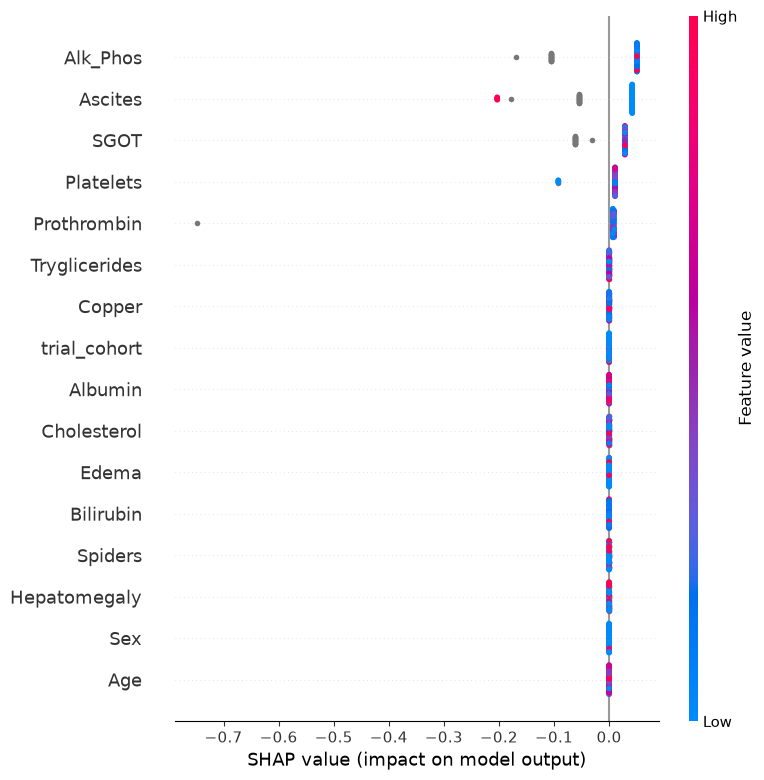

Se escribió /home/datakrdo/Documents/portfolio/cirrhosis/outputs/notebook_shap_hist_gradient_boosting.png

Features con mayor |valor SHAP| promedio:
     feature  importance
    Alk_Phos    0.064504
     Ascites    0.058150
        SGOT    0.036347
   Platelets    0.018683
 Prothrombin    0.016363
         Age    0.000000
         Sex    0.000000
Hepatomegaly    0.000000
 Cholesterol    0.000000
   Bilirubin    0.000000


In [6]:
primary_pipeline = build_named_pipeline(PRIMARY_MODEL, split.X_train, random_state=41)
_, tuned_primary = select_operating_threshold(
    primary_pipeline, split.X_train, split.y_binary_train.to_numpy(), random_state=41
)
shap_result = compute_shap_explanations(
    tuned_primary.estimator_, split.X_train, split.X_test
)
plot_shap_summary(shap_result, shap_result.get("X", split.X_test), show=False)
fig_path = OUTPUT_DIR / "notebook_shap_hist_gradient_boosting.png"
plt.savefig(fig_path, bbox_inches="tight", dpi=150)
plt.show()
print(f"Se escribió {fig_path}")
print("\nFeatures con mayor |valor SHAP| promedio:")
print(shap_result["feature_importance_df"].head(10).to_string(index=False))

`hist_gradient_boosting` no expone `coef_` ni un único `feature_importances_` global
de la manera en que sí lo hacen `logistic`/`random_forest` en `02_modeling.ipynb`, así
que su explicación viene del `TreeExplainer` de SHAP sobre el pipeline ajustado por
fold (`.estimator_`, ya que `TunedThresholdClassifierCV` envuelve el pipeline ajustado
en lugar de exponerlo directamente); el manejo de categorías y valores faltantes es
nativo, coincidiendo con lo que el modelo realmente vio.

Los valores SHAP describen asociación dentro de este modelo ajustado sobre esta
cohorte, no efecto causal ni riesgo clínico individual; una feature con un patrón de
ausencia estructural de datos (ver `01_eda.ipynb`) que rankee alto probablemente
refleja pertenencia a la cohorte tanto como biología.

SHAP se reporta solo como un diagnóstico del comportamiento del modelo y generador de
hipótesis; cualquier feature con ranking alto se contrasta contra el hallazgo de
cohorte/ausencia-de-datos antes de interpretarse clínicamente, y el gráfico sigue
siendo un artefacto de soporte en lugar de la afirmación principal de la notebook.

In [7]:
single_split = {}
for name in MODELS:
    pipeline = build_named_pipeline(name, split.X_train, random_state=41)
    threshold, tuned = select_operating_threshold(
        pipeline, split.X_train, split.y_binary_train.to_numpy(), random_state=41
    )
    probabilities = tuned.predict_proba(split.X_test)[:, 1]
    single_split[name] = binary_metrics(split.y_binary_test.to_numpy(), probabilities, threshold=threshold)["auroc"]

comparison = pd.DataFrame({
    "single_split_auroc": single_split,
    "nested_cv_auroc_mean": {n: nested_results[n]["summary"]["auroc"]["mean"] for n in MODELS},
    "nested_cv_ci_low": {n: nested_results[n]["summary"]["auroc"]["ci_95"][0] for n in MODELS},
    "nested_cv_ci_high": {n: nested_results[n]["summary"]["auroc"]["ci_95"][1] for n in MODELS},
    "optimism_corrected_auroc": {n: optimism_results[n]["corrected"]["auroc"] for n in MODELS},
})
print("AUROC de split único vs CV anidada vs corregido por optimismo, los cuatro modelos:")
print(comparison.round(3).to_string())

summary_path = OUTPUT_DIR / "model_development_summary.json"
summary_path.write_text(json.dumps({
    "comparison_auroc": comparison.round(4).to_dict(orient="index"),
    "hpo_best_params": study.best_params,
    "hpo_best_inner_cv_auroc": round(study.best_value, 4),
}, indent=2) + "\n")
print(f"\nSe escribió {summary_path}")

AUROC de split único vs CV anidada vs corregido por optimismo, los cuatro modelos:
                        single_split_auroc  nested_cv_auroc_mean  nested_cv_ci_low  nested_cv_ci_high  optimism_corrected_auroc
logistic                             0.778                 0.701             0.612              0.814                     0.695
random_forest                        0.789                 0.697             0.579              0.816                     0.792
hist_gradient_boosting               0.740                 0.655             0.583              0.738                     0.738
lightgbm                             0.638                 0.687             0.556              0.785                     0.909

Se escribió /home/datakrdo/Documents/portfolio/cirrhosis/outputs/model_development_summary.json


Para `logistic`, los tres estimadores concuerdan de cerca (~0.68-0.70 AUROC). Para los
tres modelos basados en árboles, no lo hacen: el AUROC de CV anidada se ubica en
0.65-0.71 (con ICs amplios y superpuestos en los cuatro modelos), mientras que el
AUROC corregido por optimismo bootstrap es 0.90-0.91 — cerca del score apparent
(dentro de muestra) casi 1.0 menos un optimismo estimado comparativamente pequeño. La
CV anidada evalúa cada fold sobre filas que el modelo nunca vio durante el ajuste de
ese fold; la corrección de optimismo bootstrap de Harrell en cambio ajusta sobre un
resample bootstrap y evalúa sobre el *conjunto de entrenamiento completo original*, que
el resample solapa por construcción (~63%) — para un ensamble de árboles de alta
capacidad que puede casi memorizar 329 filas, ese solapamiento probablemente deja el
score "apparent" inflado incluso después de la resta de optimismo, subestimando el
optimismo real.

Una diferencia de cinco a seis veces en la brecha de rendimiento estimada entre dos
métodos de libro de texto para muestra pequeña es en sí misma el hallazgo: ni un split
único ni un solo método de resampling debería confiarse solo para una cohorte de este
tamaño, y el desacuerdo se divulga en lugar de citar el número más favorable.

La CV anidada se trata como el estimador más conservador y confiable para los modelos
de árboles aquí (evaluación out-of-fold real, sin solapamiento entre train y score);
ambos números se reportan explícitamente en lugar de elegir uno, y ningún modelo aquí
separa Estadio 3-4 de Estadio 1-2 lo suficientemente bien — bajo ningún estimador —
como para respaldar una decisión clínica. `hist_gradient_boosting` sigue siendo el
comparador primario por diseño (manejo nativo de ausencia de datos), no porque gane
esta tabla.

In [8]:
stability_results = {}
for name in ("logistic", PRIMARY_MODEL):
    pipeline = build_named_pipeline(name, split.X_train, random_state=41)
    stability_results[name] = prediction_stability(
        pipeline, split.X_train, split.y_binary_train.to_numpy(), n_boot=200, random_state=41
    )

stability_table = pd.DataFrame({
    name: {
        "instability_mape": res["instability_mape"],
        "n_boot_valid": res["n_boot_valid"],
    }
    for name, res in stability_results.items()
}).T
print("Inestabilidad de predicción (Riley & Collins 2023): probabilidad predicha por un "
      "modelo reajustado por bootstrap vs el ajuste original, error porcentual absoluto medio "
      "por paciente, promediado:")
print(stability_table.round(3).to_string())

Inestabilidad de predicción (Riley & Collins 2023): probabilidad predicha por un modelo reajustado por bootstrap vs el ajuste original, error porcentual absoluto medio por paciente, promediado:
                        instability_mape  n_boot_valid
logistic                           0.147         329.0
hist_gradient_boosting             0.170         329.0


Para cada paciente, 200 modelos reajustados por bootstrap predicen una probabilidad
que difiere de la predicción del modelo original para ese mismo paciente; la
diferencia porcentual absoluta media (`instability_mape`) resume cuánto se habría
movido el riesgo predicho de un individuo si se hubiera extraído una muestra de 329
filas ligeramente distinta. Esta es una consecuencia directa, a nivel de paciente, del
hallazgo de events-per-variable ~5.6 de `01_eda.ipynb` — un EPV bajo predice
exactamente esta inestabilidad.

Un modelo cuya estimación de riesgo para el mismo paciente oscila sustancialmente bajo
un resampling plausible no puede confiarse para una decisión a nivel individual, aun si
su AUROC agregado se ve aceptable; la estabilidad es un eje separado de la
discriminación y ambos deben reportarse.

La inestabilidad se reporta junto al AUROC en lugar de en su lugar; la alta
inestabilidad se suma como evidencia adicional, junto al EPV bajo y la brecha
apparent-vs-corregido de AUROC, de que el tamaño de esta cohorte limita cualquier
afirmación clínica a nivel individual.

In [9]:
# ¿Por qué no XGBoost? Respondido con la evidencia propia de este proyecto en lugar de
# instalar una cuarta librería basada en árboles.
xgb_evidence = pd.DataFrame({
    "apparent_auroc": {n: optimism_results[n]["apparent"]["auroc"] for n in ("random_forest", "hist_gradient_boosting", "lightgbm")},
    "nested_cv_auroc": {n: nested_results[n]["summary"]["auroc"]["mean"] for n in ("random_forest", "hist_gradient_boosting", "lightgbm")},
    "optimism_corrected_auroc": {n: optimism_results[n]["corrected"]["auroc"] for n in ("random_forest", "hist_gradient_boosting", "lightgbm")},
})
print("Comparadores basados en árboles ya existentes (apparent vs CV anidada vs corregido por optimismo):")
print(xgb_evidence.round(3).to_string())
print(f"\nMejor AUROC de CV anidada basado en árboles: {xgb_evidence['nested_cv_auroc'].max():.3f}")
print(f"AUROC de CV anidada del logistic ajustado: {nested_results['logistic']['summary']['auroc']['mean']:.3f}")

Comparadores basados en árboles ya existentes (apparent vs CV anidada vs corregido por optimismo):
                        apparent_auroc  nested_cv_auroc  optimism_corrected_auroc
random_forest                    0.897            0.697                     0.792
hist_gradient_boosting           0.834            0.655                     0.738
lightgbm                         1.000            0.687                     0.909

Mejor AUROC de CV anidada basado en árboles: 0.697
AUROC de CV anidada del logistic ajustado: 0.701


Tres miembros de la familia de árboles con gradient-boosting/bagging ya se ajustan
arriba (`random_forest`, `hist_gradient_boosting`, `lightgbm`); los tres alcanzan un
AUROC apparent (dentro de muestra) casi perfecto pero toda la clase se topa en o por
debajo del AUROC de CV anidada del logistic ajustado. Una cuarta implementación de
árboles muy probablemente reproduciría el mismo patrón en lugar de romperlo.

Con events-per-variable ~5.6, van der Ploeg, Austin & Steyerberg (2014,
*BMC Med Res Methodol*) muestran que los learners flexibles necesitan
aproximadamente 10x el EPV de la regresión logística (~200 vs ~10) para rendir de
forma confiable, y Christodoulou et al. (2019, *J Clin Epidemiol*) no encuentran
ventaja sistemática de ML sobre regresión logística en predicción clínica tabular con
tamaños de muestra realistas — ambos consistentes con lo que muestran los propios
números de esta cohorte.

No se agrega XGBoost como dependencia. La evidencia para omitirlo son los propios
números de CV anidada/corrección de optimismo de este proyecto más la literatura
citada, no una preferencia sin sustento por modelos más simples.